In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/prasadmalaiiiitk/dataset-final-1503/sem-dataset/Augumented/Augumented/augmented_stage2/train/LER/image_12_png.rf.566726d03bb59741293c5a5c58d71f5e_aug_2.jpg
/kaggle/input/datasets/prasadmalaiiiitk/dataset-final-1503/sem-dataset/Augumented/Augumented/augmented_stage2/train/LER/image_45_png.rf.7b0c39c7948b368961c4bbc376c93d99.jpg
/kaggle/input/datasets/prasadmalaiiiitk/dataset-final-1503/sem-dataset/Augumented/Augumented/augmented_stage2/train/LER/image_43_png.rf.225187fb6b8111d171ffcccb2e905e3a_aug_0.jpg
/kaggle/input/datasets/prasadmalaiiiitk/dataset-final-1503/sem-dataset/Augumented/Augumented/augmented_stage2/train/LER/image_50_png.rf.15b257af83325aa3721cf4463a3ce1b8_aug_1.jpg
/kaggle/input/datasets/prasadmalaiiiitk/dataset-final-1503/sem-dataset/Augumented/Augumented/augmented_stage2/train/LER/image_47_png.rf.96ba9988494f51b9f661609792706976_aug_0.jpg
/kaggle/input/datasets/prasadmalaiiiitk/dataset-final-1503/sem-dataset/Augumented/Augumented/augmented_stage2/t

Download and install all dependecies

In [2]:
!pip install onnxsim
!pip install --upgrade -q grad-cam
!pip install ptflops psutil
!pip install onnxscript
!pip install onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 34.2 MB/s eta 0:00:0000:010:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 61.5 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 12.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 94.3 MB/s eta 0:00:00:00:0100:01


In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score, classification_report
import numpy as np
import shutil
import onnxruntime as ort

In [8]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32
IMG_SIZE = 224
NUM_CLASSES = 5
EPOCHS = 20
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [9]:
train_data = torchvision.datasets.ImageFolder("/kaggle/input/datasets/prasadmalaiiiitk/dataset-final-1503/sem-dataset/stage2/train", transform=train_transform)
val_data   = torchvision.datasets.ImageFolder("/kaggle/input/datasets/prasadmalaiiiitk/dataset-final-1503/sem-dataset/stage2/valid", transform=test_transform)
test_data  = torchvision.datasets.ImageFolder("/kaggle/input/datasets/prasadmalaiiiitk/dataset-final-1503/sem-dataset/stage2/test", transform=test_transform)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_data, batch_size=BATCH_SIZE)

In [10]:
model = models.mobilenet_v2(weights="IMAGENET1K_V1")

# Replace classifier
model.classifier[1] = nn.Linear(model.last_channel, 5)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 122MB/s]


MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader)}")

Epoch 1, Loss: 0.7107116389088333
Epoch 2, Loss: 0.3991423256229609
Epoch 3, Loss: 0.28491346212103963
Epoch 4, Loss: 0.2712978816125542
Epoch 5, Loss: 0.20553686982020736
Epoch 6, Loss: 0.1965209386544302
Epoch 7, Loss: 0.13793345564045012
Epoch 8, Loss: 0.13629555172519758
Epoch 9, Loss: 0.16491846102871932
Epoch 10, Loss: 0.10750944055325817


In [13]:
import torch
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
model.eval()
correct = 0
total = 0


all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


accuracy = 100 * correct / total
print(f"Validation Accuracy: {accuracy:.2f}%")
f1  = f1_score(all_labels, all_preds, average='weighted')
print(f"F1 Score: {f1:.4f}")

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# 🔥 Classification report (includes precision, recall, F1)
print(classification_report(all_labels, all_preds, target_names=test_data.classes))

# 🔥 Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:\n", cm)


Validation Accuracy: 75.00%
F1 Score: 0.7474
               precision    recall  f1-score   support

          LER       0.64      0.70      0.67        10
        crack       0.67      0.73      0.70        11
malformed_via       0.67      0.80      0.73        10
         open       0.82      0.88      0.85        26
        short       0.85      0.58      0.69        19

     accuracy                           0.75        76
    macro avg       0.73      0.74      0.73        76
 weighted avg       0.76      0.75      0.75        76

Confusion Matrix:
 [[ 7  0  0  2  1]
 [ 1  8  2  0  0]
 [ 1  1  8  0  0]
 [ 0  0  2 23  1]
 [ 2  3  0  3 11]]


using Grad-CAN

In [40]:
import torch
import os
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# -----------------------
# 1️⃣ Load Model
# -----------------------

#model = torch.load("model_full.pth", weights_only=False)
model.eval()

# Enable gradients (IMPORTANT for Grad-CAM)
for param in model.parameters():
    param.requires_grad = True

# -----------------------
# 2️⃣ Setup Grad-CAM
# -----------------------

target_layers = [model.features[-1][0]]  # MobileNetV3
cam = GradCAM(model=model, target_layers=target_layers)

# -----------------------
# 3️⃣ Output Root
# -----------------------

output_root = "structured_gradcam"
os.makedirs(output_root, exist_ok=True)

class_names = test_data.classes
num_classes = len(class_names)

# -----------------------
# 4️⃣ Loop Over Entire Test Dataset
# -----------------------

for idx in range(len(test_data)):

    img, label = test_data[idx]
    true_class = class_names[label]

    # Create folder for TRUE class
    true_class_folder = os.path.join(output_root, f"True_{true_class}")
    os.makedirs(true_class_folder, exist_ok=True)

    # Create subfolder per image
    image_folder = os.path.join(true_class_folder, f"image_{idx}")
    os.makedirs(image_folder, exist_ok=True)

    input_tensor = img.unsqueeze(0).to(0)

    # Prepare image for overlay
    rgb_img = img.permute(1, 2, 0).cpu().numpy()
    rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min())

    # -----------------------
    # 5️⃣ Generate CAM for ALL classes
    # -----------------------

    for class_idx in range(num_classes):

        target_class_name = class_names[class_idx]

        targets = [ClassifierOutputTarget(class_idx)]
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
        grayscale_cam = grayscale_cam[0]

        visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

        save_path = os.path.join(
            image_folder,
            f"cam_{target_class_name}.png"
        )

        plt.imsave(save_path, visualization)

print("Structured Grad-CAM generation completed.")

Structured Grad-CAM generation completed.


In [41]:
 shutil.make_archive(
        base_name="/kaggle/working/MobilNetV2_structured_gradcam_results",
        format="zip",
        root_dir="/kaggle/working/structured_gradcam"
    )

print("Zip file created successfully!")

Zip file created successfully!


In [43]:
torch.save(model, "mobilenetv2_sem.pth")

In [44]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(0)
        outputs = model(inputs)
        preds = outputs.argmax(dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

class_names = test_data.classes

In [45]:
accuracy = np.mean(all_preds == all_labels)
print("Overall Accuracy:", accuracy)

Overall Accuracy: 0.7530864197530864


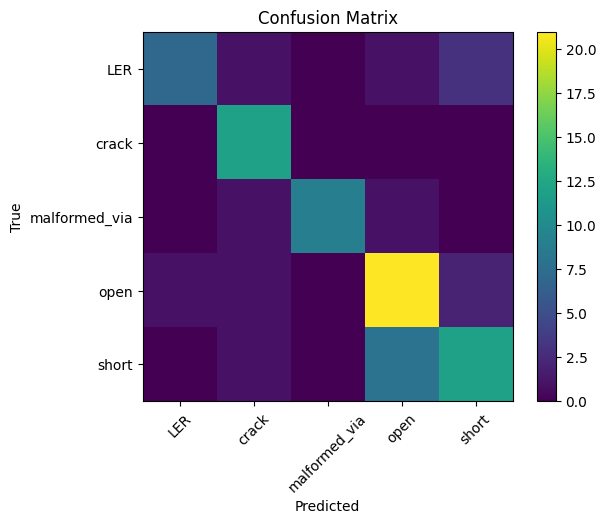

In [46]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure()
plt.imshow(cm)
plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.show()

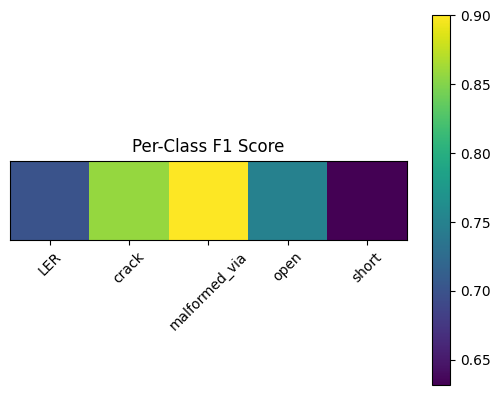

In [47]:
report = classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    output_dict=True
)

f1_scores = [report[c]["f1-score"] for c in class_names]

plt.figure()
plt.imshow(np.array(f1_scores).reshape(1, -1))
plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks([])
plt.title("Per-Class F1 Score")
plt.colorbar()
plt.show()

Check the edge suitability for the model

In [57]:
import torch
import time
import os
import psutil
from ptflops import get_model_complexity_info

MODEL_PATH = "/kaggle/working/mobilenetv2_sem.pth"

# ----------------------------
# Device setup
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------------------
# Load model
model = torch.load(MODEL_PATH, weights_only=False)
model = model.to(device)
model.eval()

print("\n===== MODEL BENCHMARK =====\n")

# ----------------------------
# Model size
# ----------------------------
model_size = os.path.getsize(MODEL_PATH)/(1024*1024)
print("Model size:", round(model_size,2), "MB")

# ----------------------------
# Parameter count
# ----------------------------
params = sum(p.numel() for p in model.parameters())
print("Parameters:", params)

# ----------------------------
# FLOPs
# ----------------------------
macs, _ = get_model_complexity_info(
    model,
    (3,224,224),
    as_strings=False,
    print_per_layer_stat=False
)

flops = macs * 2

print("FLOPs:", round(flops/1e6,2), "MFLOPs")

# ----------------------------
# Inference latency
# ----------------------------
dummy = torch.randn(1,3,224,224).to(device)

# warmup
for _ in range(10):
    model(dummy)

runs = 100

start = time.time()

with torch.no_grad():
    for _ in range(runs):
        model(dummy)

end = time.time()

latency = (end-start)/runs*1000
fps = 1000/latency

print("Latency:", round(latency,2), "ms")
print("Throughput:", round(fps,2), "FPS")

# ----------------------------
# Memory usage
# ----------------------------
process = psutil.Process(os.getpid())
memory = process.memory_info().rss/(1024*1024)

print("RAM usage:", round(memory,2), "MB")

# ----------------------------
# Edge suitability score
# ----------------------------
score = 0

if model_size < 10:
    score += 1
if params < 5_000_000:
    score += 1
if latency < 100:
    score += 1
if flops < 500e6:
    score += 1

levels = ["Poor","Moderate","Good","Excellent"]

print("\nEdge suitability:", levels[score-1] if score>0 else "Poor")
print("score", score)


===== MODEL BENCHMARK =====

Model size: 9.26 MB
Parameters: 2230277
FLOPs: 638.05 MFLOPs
Latency: 5.5 ms
Throughput: 181.7 FPS
RAM usage: 1928.86 MB

Edge suitability: Good
score 3


In [49]:
model.cpu()
model.eval()

dummy_input = torch.randn(1, 3, 224, 224)

torch.onnx.export(
    model,
    dummy_input,
    "model.onnx",
    input_names=["input"],
    output_names=["output"],
    opset_version=17,       # 🔥 important
    dynamic_axes=None       # 🔥 avoid shape issues
)

print("ONNX model exported ✅")

W0329 04:12:43.724000 55 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0329 04:12:44.519000 55 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0329 04:12:44.520000 55 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, ali

[torch.onnx] Obtain model graph for `MobileNetV2([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `MobileNetV2([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).
Failed to convert the model to the target version 17 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 104 of general pattern rewrite rules.
ONNX model exported ✅


In [50]:
import onnx
from onnxsim import simplify

model_onnx = onnx.load("model.onnx")
model_simplified, check = simplify(model_onnx)

assert check, "Simplified ONNX model is invalid"

onnx.save(model_simplified, "model_sim.onnx")
print("ONNX simplified ✅")

ONNX simplified ✅


In [51]:



session = ort.InferenceSession("model_sim.onnx")

# same dummy input
torch_out = model(dummy_input).detach().numpy()
onnx_out = session.run(None, {"input": dummy_input.numpy()})

print("Torch:", torch_out[0][:5])
print("ONNX :", onnx_out[0][0][:5])

print("Torch pred:", np.argmax(torch_out))
print("ONNX pred :", np.argmax(onnx_out[0]))

Torch: [ 0.19373557  0.31329876 -2.5579119   1.700355   -1.0579098 ]
ONNX : [ 0.19373554  0.3132988  -2.5579126   1.700355   -1.0579101 ]
Torch pred: 3
ONNX pred : 3


In [52]:
from onnxruntime.quantization import quantize_dynamic, QuantType

quantize_dynamic(
    model_input="model_sim.onnx",
    model_output="MobilnetV2_model_int8.onnx",
    weight_type=QuantType.QInt8
)

print("Quantization complete ✅")

Quantization complete ✅


In [58]:
import onnx
import onnxruntime as ort
import numpy as np
import time
import os
import psutil

MODEL_PATH = "/kaggle/working/MobilnetV2_model_int8.onnx"

print("\n===== Quantise ONNX MODEL BENCHMARK =====\n")

# ----------------------------
# Model size
# ----------------------------
model_size = os.path.getsize(MODEL_PATH)/(1024*1024)
print("Model size:", round(model_size,2), "MB")

# ----------------------------
# Load ONNX model
# ----------------------------
session = ort.InferenceSession(MODEL_PATH)

input_name = session.get_inputs()[0].name
input_shape = session.get_inputs()[0].shape

print("Input shape:", input_shape)

# ----------------------------
# Parameter count (approx)
# ----------------------------
onnx_model = onnx.load(MODEL_PATH)

param_count = 0
for tensor in onnx_model.graph.initializer:
    param_count += np.prod(tensor.dims)

print("Parameters:", int(param_count))

# ----------------------------
# FLOPs (approx using onnx tool)
# ----------------------------
try:
    from onnx_tool import model_profile

    profile = model_profile(onnx_model)
    flops = profile["flops"]

    print("FLOPs:", round(flops/1e6,2), "MFLOPs")

except:
    print("FLOPs: Install 'onnx-tool' for FLOPs calculation")

# ----------------------------
# Inference latency
# ----------------------------
dummy = np.random.randn(1,3,224,224).astype(np.float32)

# warmup
for _ in range(10):
    session.run(None, {input_name: dummy})

runs = 100

start = time.time()

for _ in range(runs):
    session.run(None, {input_name: dummy})

end = time.time()

latency = (end-start)/runs*1000
fps = 1000/latency

print("Latency:", round(latency,2), "ms")
print("Throughput:", round(fps,2), "FPS")

# ----------------------------
# Memory usage
# ----------------------------
process = psutil.Process(os.getpid())
memory = process.memory_info().rss/(1024*1024)

print("RAM usage:", round(memory,2), "MB")

# ----------------------------
# Edge suitability score
# ----------------------------
score = 0

if model_size < 10:
    score += 1
if param_count < 5_000_000:
    score += 1
if latency < 100:
    score += 1
if 'flops' in locals() and flops < 500e6:
    score += 1



levels = ["Poor","Moderate","Good","Excellent"]

print("\nEdge suitability:", levels[score-1] if score>0 else "Poor")
print("score",score )


===== Quantise ONNX MODEL BENCHMARK =====

Model size: 2.23 MB
Input shape: [1, 3, 224, 224]
Parameters: 2213541
FLOPs: Install 'onnx-tool' for FLOPs calculation
Latency: 99.53 ms
Throughput: 10.05 FPS
RAM usage: 1939.43 MB

Edge suitability: Good
score 3
